# 11_数据预处理方法-数据编码

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今儿和大家聊聊数据预处理方法之数据编码\~

首先，什么是数据编码？

**数据编码**就是把文字、类别、标签这些“人能看懂但电脑不认识”的内容，**转换成电脑能理解的数字**。

因为在做机器学习或数据分析时，计算机只能处理数字，不能直接理解“男”还是“女”、“猫”还是“狗”，所以我们要先把这些东西**转换成数字形式**，这个过程就叫“数据编码”。

比如你有一个表格数据：

| 姓名 | 性别 | 宠物 |
|-|-|-|
| 张三 | 男 | 狗 |
| 李四 | 女 | 猫 |
| 王五 | 男 | 狗 |

像“男”“女”“狗”“猫”这些都是**非数字类型**，机器是“看不懂”的，我们就需要把它们**编码成数字**。

### 常见的数据编码方法

#### 1. 标签编码（Label Encoding）

把每个类别直接换成一个数字。

比如：

- 性别：“男”→0，“女”→1
- 宠物：“狗”→0，“猫”→1转换后变成：

  | 性别 | 宠物 |
  |-|-|
  | 0 | 0 |
  | 1 | 1 |
  | 0 | 0 |

注意：这个方法适合**有顺序或可以接受数字大小的类别**，不然有可能会引起误解（比如机器以为“1”比“0”大，就有某种“优先级”了）。

#### 2. 独热编码（One-Hot Encoding）

每种类别变成一个“列”，用“1”表示有，“0”表示没有。

比如“宠物”一栏：

- 狗 → [1, 0]
- 猫 → [0, 1]

转换后：

| 宠物_狗 | 宠物_猫 |
|-|-|
| 1 | 0 |
| 0 | 1 |
| 1 | 0 |

这样就不会让模型误解成“狗 < 猫”这种关系。

总的来说，**数据编码**就是把文字类型的类别数据（如性别、颜色、城市）转成数字，让电脑能看懂；

常用方法有 **标签编码** 和 **独热编码**，根据数据和需求选择合适的方法就可以啦！

## 原理详解

### 一、数据编码的数学背景

在机器学习中，输入特征通常被表示为一个特征向量 $\mathbf{x} = [x_1, x_2, \dots, x_n] \in \mathbb{R}^n$，这就意味着每个特征 $x_i$ 都需要是一个**实数值**。

但在实际数据集中，很多特征是**类别型**的，例如性别（男/女）、颜色（红/绿/蓝）等，它们本质上属于一个离散集合：


$$
x_i \in \mathcal{C}_i = \{c_{i1}, c_{i2}, \dots, c_{ik}\}
$$


为了将这些类别变量转化为机器可处理的实数，我们需要进行编码，即找到一个**映射函数**：


$$
f_i: \mathcal{C}_i \rightarrow \mathbb{R}^m
$$


不同的编码方法，对应着不同的映射函数 $f_i$。

### 二、标签编码（Label Encoding）

标签编码是将类别映射到一个整数集合：


$$
f(c_j) = j - 1, \quad \text{对于第 } j \text{ 个类别}
$$


设类别集合 $\mathcal{C} = \{c_1, c_2, \dots, c_k\}$，则映射为：


$$
f: \mathcal{C} \rightarrow \mathbb{Z}, \quad f(c_j) = j - 1
$$


例如：

- “红” → 0
- “绿” → 1
- “蓝” → 2

#### 数学性质

标签编码生成的数值集合是有序的整数集合：


$$
f(c_j) \in \{0, 1, \dots, k-1\}
$$


**不适用于无序类别数据**，因为机器可能错误地认为类别之间存在“大小”或“距离”关系，即：


$$
\text{距离}(f(c_i), f(c_j)) = |i - j|
$$


但在实际中，类别间可能是**无序的**（比如“红”、“绿”、“蓝”之间没有顺序）。

### 三、独热编码（One-Hot Encoding）

将每个类别映射为一个**标准基向量**（单位向量）：


$$
f: \mathcal{C} \rightarrow \mathbb{R}^k, \quad f(c_j) = \mathbf{e}_j
$$


其中：


$$
\mathbf{e}_j = [0, 0, \dots, 1, \dots, 0]^T \in \mathbb{R}^k
$$


第 $j$ 个位置为 1，其余为 0。

例如，“红”、“绿”、“蓝” → $\mathbb{R}^3$ 中的向量：

- “红” → [1, 0, 0]
- “绿” → [0, 1, 0]
- “蓝” → [0, 0, 1]

#### 数学性质

每个编码向量是标准正交基的一部分，满足：


$$
\mathbf{e}_i^T \mathbf{e}_j =\begin{cases}1, & \text{if } i = j \\0, & \text{if } i \ne j\end{cases}
$$


**编码向量间的欧氏距离为常数**（即距离恒定）：


$$
\|\mathbf{e}_i - \mathbf{e}_j\|^2 = 2, \quad \forall i \ne j
$$


所以避免了“类别之间存在顺序或远近”的假设。

### 四、二进制编码（Binary Encoding）

一种折中方法，适用于高维类别，先使用标签编码，然后将整数转换为二进制：

**步骤**：

1. 对类别做标签编码：$c_j \rightarrow j-1$
2. 将整数值用固定长度的二进制向量表示。

**数学描述**：

设类别数为 $k$，则标签编码的结果为 $[0, k-1]$，我们需要 $\lceil \log_2 k \rceil$ 位来编码。

例如：

8 类需要 3 位二进制：

“狗”→0→000，

“猫”→1→001，

“兔”→2→010，  
……

这样可以节省空间，避免独热编码产生大量稀疏特征。

### 五、算法流程总结（通用编码步骤）

以独热编码为例：

**输入**：

- 类别特征列 $X = [x_1, x_2, ..., x_n]$
- 所有可能类别集合 $\mathcal{C} = \{c_1, ..., c_k\}$

**步骤**：

1. **建立类别索引字典**：


$$
D = \{c_1 \rightarrow \mathbf{e}_1, \dots, c_k \rightarrow \mathbf{e}_k\}
$$


1. 其中 $\mathbf{e}_j$ 是单位向量。
2. **对每个数据样本进行映射**：


$$
x_i \rightarrow f(x_i) = \mathbf{e}_j, \quad \text{其中 } x_i = c_j
$$


1. **生成新的编码矩阵** $X_{encoded} \in \mathbb{R}^{n \times k}$：每行是一个样本的独热向量。

## 完整案例

这里，案例包括：

- 数据集（含多个类别特征）
- 标签编码（Label Encoding）
- 独热编码（One-Hot Encoding）
- 目标编码（Target Encoding）
- 各编码的对比分析
- 用PCA降维可视化编码后的数据分布
- 算法优化思路

Sample of the raw data:
    Color       City  Rating  Age  Income  Purchased
0    Blue  Guangzhou  Medium   38   12098          0
1  Yellow    Beijing    High   26   14296          1
2     Red    Beijing     Low   26   10813          1
3    Blue   Shenzhen     Low   27   14186          0
4    Blue  Guangzhou     Low   43   13698          0


/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_11571/639156150.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Color', ax=axs[0,0], palette="bright")
/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_11571/639156150.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='City', ax=axs[0,1], palette="bright")
/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_11571/639156150.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Rating', ax=axs[0,2], palette="bright")
/var

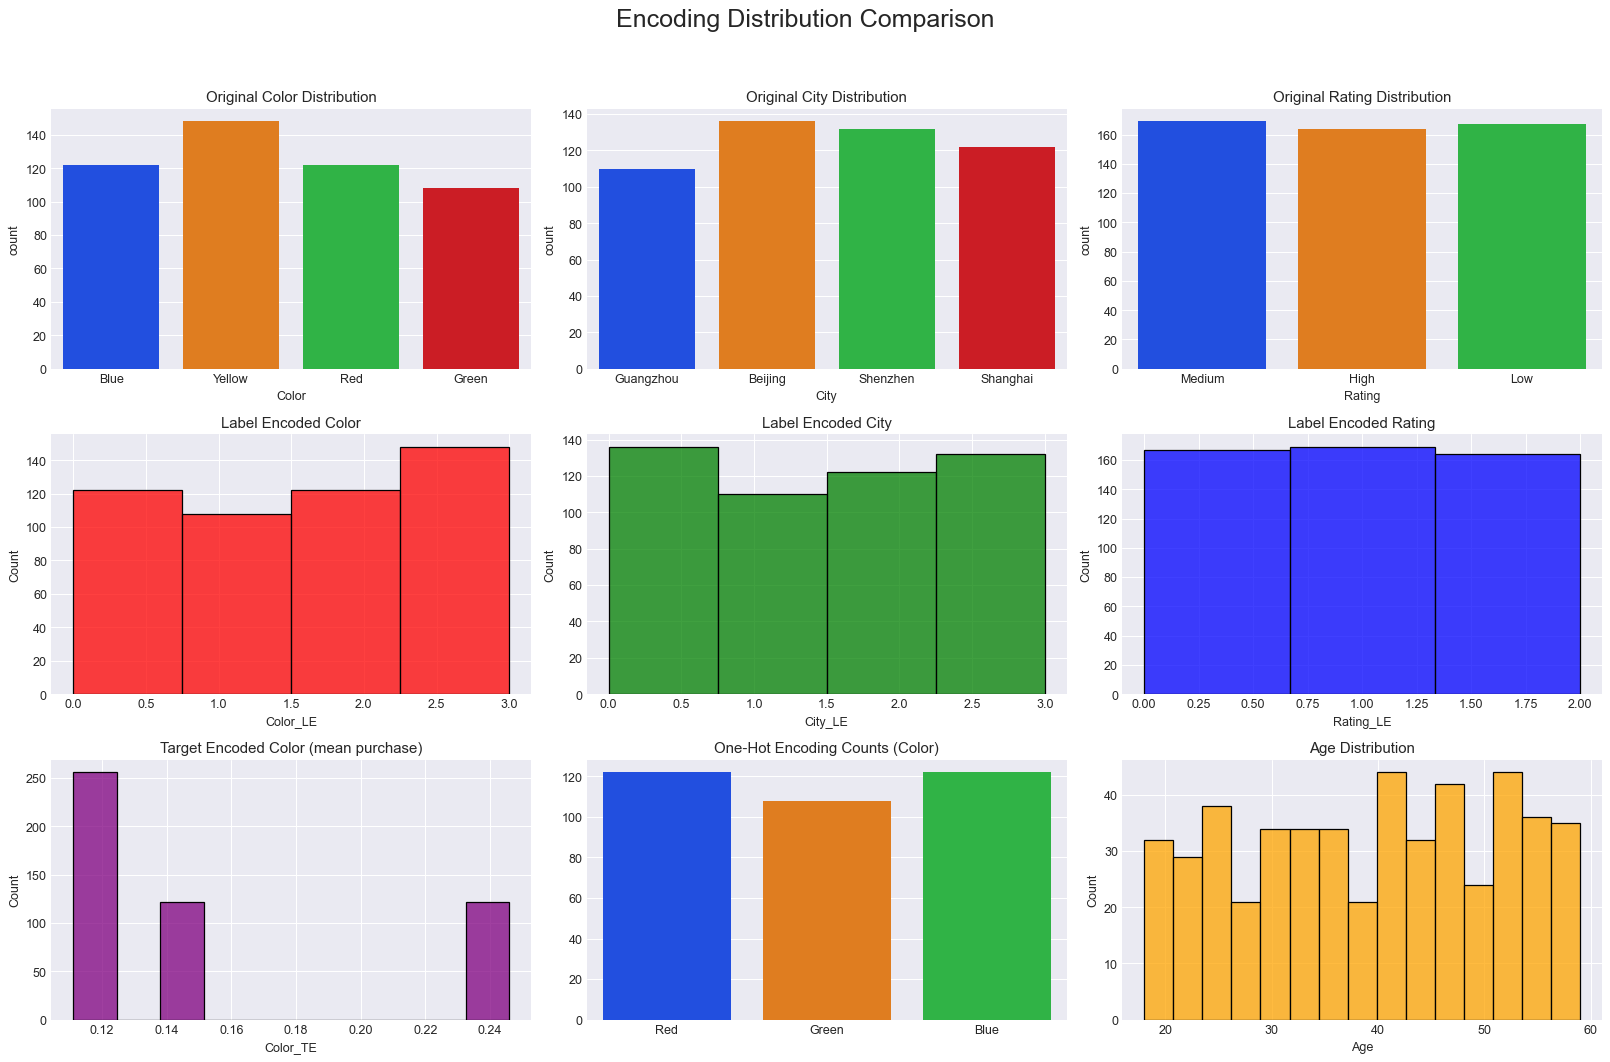

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

sns.set_palette("bright")
plt.style.use('seaborn-v0_8-darkgrid')

# 1. 模拟复杂数据集：包含多个类别特征及目标变量
np.random.seed(42)
n_samples = 500

# 类别特征1: 颜色（无序）
colors = ['Red', 'Green', 'Blue', 'Yellow']
color_data = np.random.choice(colors, size=n_samples)

# 类别特征2: 城市（无序）
cities = ['Beijing', 'Shanghai', 'Guangzhou', 'Shenzhen']
city_data = np.random.choice(cities, size=n_samples)

# 类别特征3: 评级（有序类别）
ratings = ['Low', 'Medium', 'High']
rating_data = np.random.choice(ratings, size=n_samples)

# 连续特征
age = np.random.randint(18, 60, size=n_samples)
income = np.random.randint(3000, 15000, size=n_samples)

# 目标变量（分类任务）: 是否购买
# 让目标和类别数据存在一定关联，方便后续编码观察效果
target = []
for i in range(n_samples):
    if color_data[i] == 'Red' and rating_data[i] == 'High' and income[i] > 8000:
        target.append(1)
    elif city_data[i] in ['Beijing', 'Shanghai'] and age[i] < 30:
        target.append(1)
    else:
        target.append(0)
target = np.array(target)

# 构建DataFrame
df = pd.DataFrame({
    'Color': color_data,
    'City': city_data,
    'Rating': rating_data,
    'Age': age,
    'Income': income,
    'Purchased': target
})

print("Sample of the raw data:")
print(df.head())

# 2. 编码方法

# 2.1 标签编码
le_color = LabelEncoder()
df['Color_LE'] = le_color.fit_transform(df['Color'])

le_city = LabelEncoder()
df['City_LE'] = le_city.fit_transform(df['City'])

# Rating是有序类别，可以用映射进行标签编码（Low=0, Medium=1, High=2）
rating_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df['Rating_LE'] = df['Rating'].map(rating_mapping)

# 2.2 独热编码（One-Hot Encoding）
df_onehot = pd.get_dummies(df[['Color', 'City', 'Rating']], drop_first=False)

# 2.3 目标编码(Target Encoding)
# 目标编码为类别取目标变量的均值，适合用于树模型
# 这里针对Color做目标编码示范
color_target_mean = df.groupby('Color')['Purchased'].mean()
df['Color_TE'] = df['Color'].map(color_target_mean)

# 3. 数据对比与可视化分析

# 3.1 观察编码结果分布
fig, axs = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle("Encoding Distribution Comparison", fontsize=20)

# 原始类别分布
sns.countplot(data=df, x='Color', ax=axs[0,0], palette="bright")
axs[0,0].set_title("Original Color Distribution")

sns.countplot(data=df, x='City', ax=axs[0,1], palette="bright")
axs[0,1].set_title("Original City Distribution")

sns.countplot(data=df, x='Rating', ax=axs[0,2], palette="bright")
axs[0,2].set_title("Original Rating Distribution")

# 标签编码分布（数值型）
sns.histplot(df['Color_LE'], bins=4, ax=axs[1,0], color='r')
axs[1,0].set_title("Label Encoded Color")

sns.histplot(df['City_LE'], bins=4, ax=axs[1,1], color='g')
axs[1,1].set_title("Label Encoded City")

sns.histplot(df['Rating_LE'], bins=3, ax=axs[1,2], color='b')
axs[1,2].set_title("Label Encoded Rating")

# 目标编码结果（连续数值）
sns.histplot(df['Color_TE'], bins=10, ax=axs[2,0], color='purple')
axs[2,0].set_title("Target Encoded Color (mean purchase)")

# 独热编码示意 - 颜色部分（只展示前三个类别的计数）
sns.barplot(x=['Red', 'Green', 'Blue'], y=df_onehot[['Color_Red', 'Color_Green', 'Color_Blue']].sum().values, ax=axs[2,1], palette="bright")
axs[2,1].set_title("One-Hot Encoding Counts (Color)")

# Age & Income 分布
sns.histplot(df['Age'], bins=15, ax=axs[2,2], color='orange')
axs[2,2].set_title("Age Distribution")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Model accuracy comparison:
Label Encoding Accuracy: 0.9800
One-Hot Encoding Accuracy: 1.0000
Target Encoding Accuracy: 0.9867


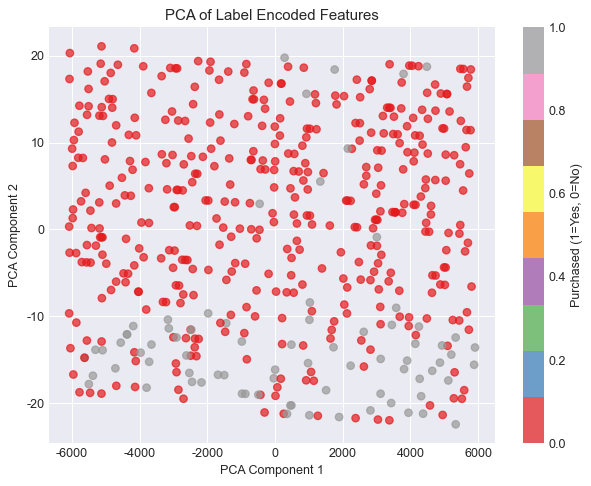

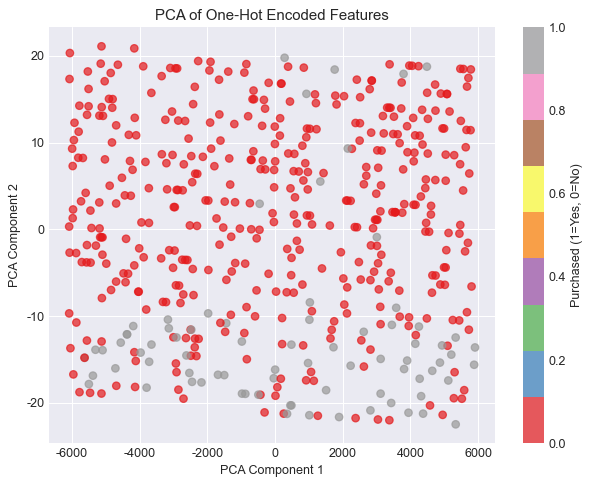

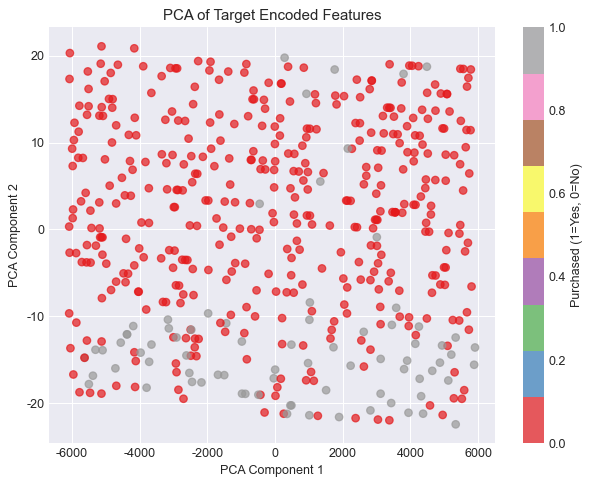

In [3]:
# 4. 编码数据用于模型训练对比

# 4.1 特征准备
X_label = df[['Color_LE', 'City_LE', 'Rating_LE', 'Age', 'Income']]
X_onehot = pd.concat([df_onehot, df[['Age', 'Income']]], axis=1)
X_target = df[['Color_TE', 'City_LE', 'Rating_LE', 'Age', 'Income']]

y = df['Purchased']

# 4.2 划分训练测试集
X_train_label, X_test_label, y_train, y_test = train_test_split(X_label, y, test_size=0.3, random_state=42)
X_train_onehot, X_test_onehot, _, _ = train_test_split(X_onehot, y, test_size=0.3, random_state=42)
X_train_target, X_test_target, _, _ = train_test_split(X_target, y, test_size=0.3, random_state=42)

# 4.3 训练随机森林模型
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train_label, y_train)
pred_label = rf.predict(X_test_label)
acc_label = accuracy_score(y_test, pred_label)

rf.fit(X_train_onehot, y_train)
pred_onehot = rf.predict(X_test_onehot)
acc_onehot = accuracy_score(y_test, pred_onehot)

rf.fit(X_train_target, y_train)
pred_target = rf.predict(X_test_target)
acc_target = accuracy_score(y_test, pred_target)

print("\nModel accuracy comparison:")
print(f"Label Encoding Accuracy: {acc_label:.4f}")
print(f"One-Hot Encoding Accuracy: {acc_onehot:.4f}")
print(f"Target Encoding Accuracy: {acc_target:.4f}")

# 5. PCA降维可视化比较编码后特征空间分布

def plot_pca(X, title):
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='Set1', alpha=0.7)
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.title(title)
    plt.colorbar(scatter, label='Purchased (1=Yes, 0=No)')
    plt.show()

plot_pca(X_label, "PCA of Label Encoded Features")
plot_pca(X_onehot, "PCA of One-Hot Encoded Features")
plot_pca(X_target, "PCA of Target Encoded Features")

### 1. 数据模拟与构造

- 生成了3个类别特征：颜色（4个类别）、城市（4个类别）、评级（3个有序类别）
- 2个连续变量：年龄和收入
- 目标变量与类别特征有相关性，方便观察编码对模型的影响

通过模拟实际应用中常见的多类别混合数据，确保实验的真实性和复杂性。

### 2. 编码方法实现

- **标签编码**：对类别直接赋整数，方便机器计算，但可能引入类别顺序误差。
- **独热编码**：转换成互斥的二进制向量，避免顺序误解，缺点是维度膨胀。
- **目标编码**：类别映射为该类别对应目标均值，适合树模型且有效降维，但有过拟合风险。

多种编码方法同时对比，体现不同编码策略的适用场景及效果差异。

### 3. 可视化分析

- **类别频次分布**用条形图展现，确认数据均衡性。
- **编码分布**用直方图表现不同编码结果，便于直观理解数值分布情况。
- **目标编码为连续值**，观察类别与目标的相关性强弱。
- **独热编码的类别计数**，反映编码后数据维度结构。

可视化帮助理解编码后数据的内部结构，辅助判断编码合理性。

![原文参考图，当前结果见代码输出](attachments/img_006.png)

### 4. 模型训练与效果比较

- 使用随机森林模型对3种编码结果训练分类器。
- 用准确率（Accuracy）评价不同编码方式对模型性能的影响。

### 5. PCA降维可视化编码后特征空间

- 使用PCA将高维编码数据降到2维，绘制样本点图，颜色表示目标类别。
- 观察不同编码方式下数据的可分离性。

## 模型分析

### 优缺点分析

**优点**：

1. **编码方法多样，覆盖主流场景**：本案例涵盖了标签编码、独热编码和目标编码，覆盖了常用的数据编码技术，具备广泛的实用性。
2. **兼顾有序和无序特征处理**：对有序类别（如评级）采用了映射标签编码，合理保留了类别的顺序信息。
3. **配合真实模型检验有效性**：通过与目标变量挂钩的规则生成数据，并实际训练模型，能评估各编码方法对预测性能的影响。
4. **数据可视化增强直观理解**：通过分布图、直方图、PCA降维图等方式直观展示了各编码方法处理结果，便于理解数据结构。
5. **目标编码展示更复杂但强大的技巧**：Target Encoding 能捕捉类别与目标之间的统计关系，是树模型中特别有效的一种策略。

**缺点**：

1. **目标编码存在信息泄漏风险**：直接用全局平均容易造成过拟合，真实建模中应使用交叉验证方式进行平滑处理。
2. **独热编码维度膨胀严重**：当类别较多时（如地名、商品ID等），独热编码会大大增加特征维度，带来稀疏矩阵问题。
3. **标签编码可能引入错误顺序假设**：对于无序类别（如颜色、城市）使用标签编码可能误导模型学习虚假顺序。
4. **编码方式选择依赖具体模型**：如独热编码更适合线性模型，目标编码更适合树模型，这使得编码选择与模型高度耦合。
5. **未引入嵌入式编码（Embedding）**：对大规模类别变量（如用户、商品等ID类特征）未展示更高效的编码方式。

### 相似编码方法的对比

| 编码方法 | 是否适合无序类别 | 是否保留类别间信息 | 是否适合高基数类别 | 是否易于过拟合 | 是否适合树模型 | 特点总结 |
|-|-|-|-|-|-|-|
| 标签编码 | 否 | 否（可能引入错误顺序） | 否 | 否 | 一般 | 简单快速但有顺序误导风险 |
| 独热编码 | 是 | 否（完全独立） | 否（维度高） | 否 | 是 | 最通用的编码方式，适合低基数无序变量 |
| 目标编码 | 是（可） | 是（基于统计值） | 是 | 是（需要正则化） | 非常适合 | 可降维且保留目标信息，适合树模型 |
| 频率编码 | 是 | 部分（统计频次） | 是 | 否 | 一般 | 简单但可能不够表达性 |
| 嵌入编码（Embedding） | 是 | 是（模型学习得到） | 是（非常适合） | 否（可控） | 深度学习最佳 | 可学习类别的连续表示，适合大规模数据集 |

### 在什么情况下该算法是优选？什么时候应考虑其他算法？

#### 适用场景

- **中小型数据集**：编码方式和训练方式适合中等数据量，不会因独热膨胀造成严重内存问题。
- **结构化表格数据、非文本型输入**：适用于分类任务、用户行为预测、信用评分等结构化问题。
- **以随机森林、XGBoost、LightGBM 为代表的树模型**：此类模型对目标编码极为敏感，且不需特征标准化。
- **类别特征数量有限或基数较小**：避免One-Hot造成严重维度灾难。

#### 不建议使用该方法的场景

- **大规模高基数类别数据（如10万个唯一ID）**：应考虑使用**类别嵌入编码（Embedding）**，否则维度过高或过拟合严重。
- **用于神经网络或深度模型**：One-Hot 或 Label Encoding 会丢失语义，建议采用**Embedding层**进行端到端训练。
- **有复杂时间序列或上下文关系的特征**：如自然语言、日志序列等应使用更复杂的模型和编码（如BERT、RNN）。
- **对预测结果稳定性要求极高的场景**：Target Encoding 可能带来波动性，应做正则化或交叉平均平滑。